# Customer Intelligence System
**End-to-end pipeline:** EDA → Clustering (K-Means, DBSCAN) → Classification (Random Forest, XGBoost Ensemble)

**Dataset:** [Unsupervised Learning on Country Data – Kaggle](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

## 1. Imports & Setup

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import shutil
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, silhouette_score
from sklearn.decomposition import PCA
from xgboost import XGBClassifier


# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
print("Path to dataset files:", path)

# Save directly to root folder (current working directory)
destination = "./"   # root of your project

# Copy dataset files into root
shutil.copytree(path, destination, dirs_exist_ok=True)

print(f"Dataset saved in root folder: {os.path.abspath(destination)}")


plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
np.random.seed(42)
print("Libraries loaded successfully.")

Path to dataset files: C:\Users\ranja\.cache\kagglehub\datasets\rohan0301\unsupervised-learning-on-country-data\versions\2
Dataset saved in root folder: d:\Users\Desktop\Desktop\College\Masters\3rd Semester\Internship\Github
Libraries loaded successfully.


## 2. Load Data


In [5]:
df = pd.read_csv("Country-data.csv").drop(columns="country")
FEATURES = df.columns.tolist()

## 3. Exploratory Data Analysis

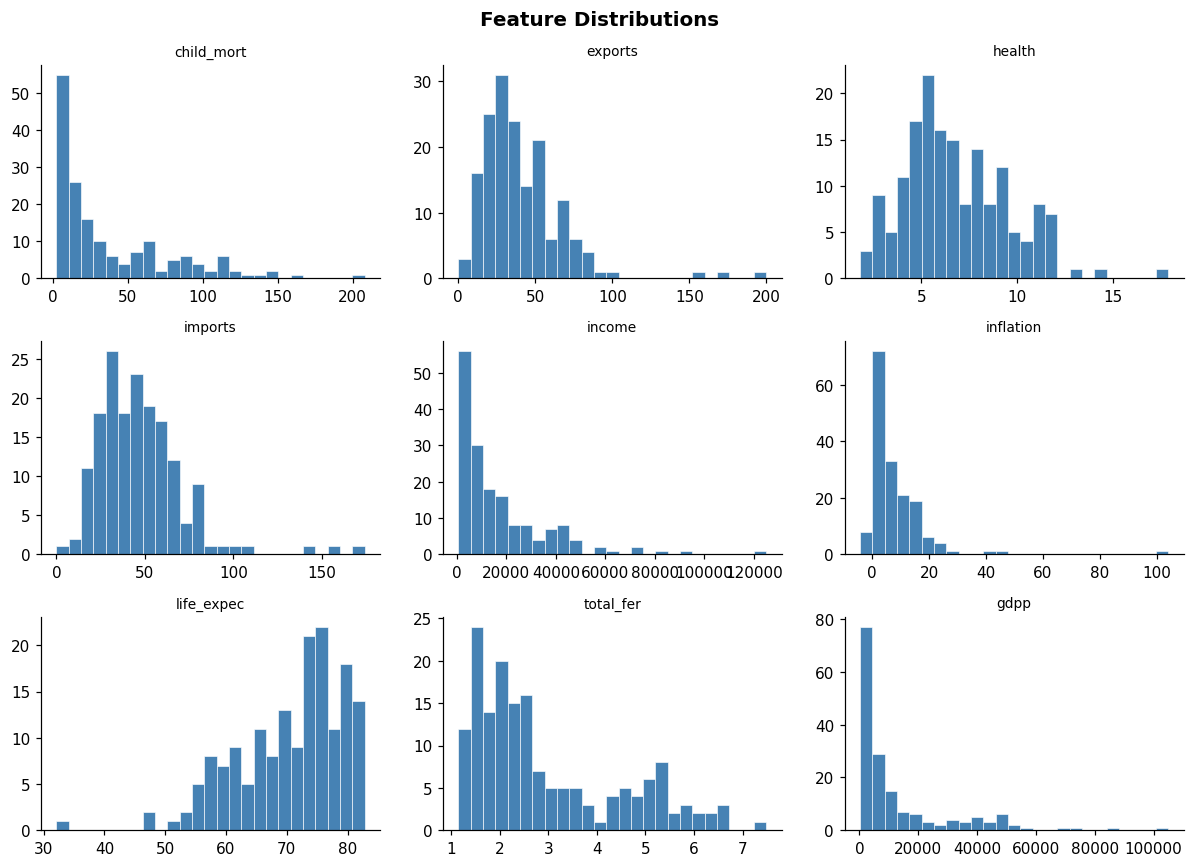

In [6]:
# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
fig.suptitle("Feature Distributions", fontsize=13, fontweight="bold")
for ax, col in zip(axes.flat, FEATURES):
    ax.hist(df[col], bins=25, edgecolor="white", linewidth=0.4, color="steelblue")
    ax.set_title(col, fontsize=9)
fig.tight_layout()
plt.show()

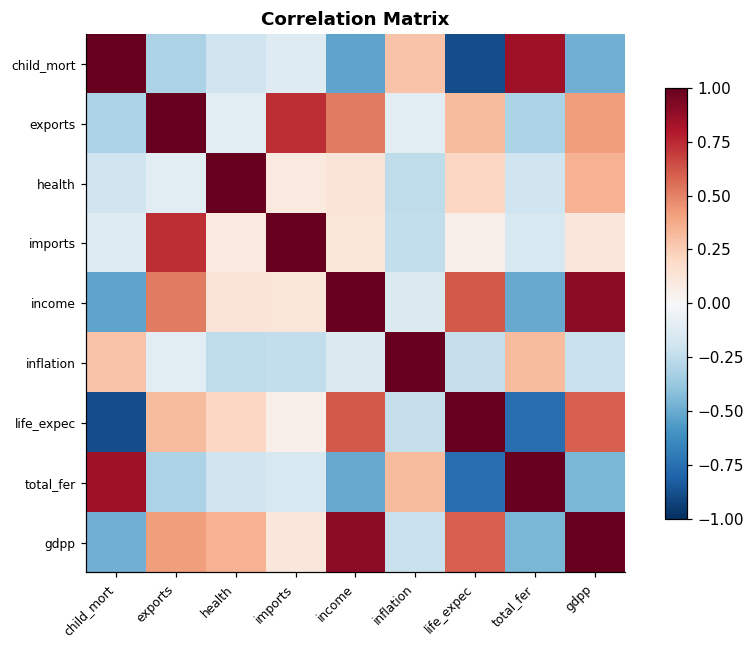

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(FEATURES, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Matrix", fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Preprocessing

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES].values)

pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
print(f"Variance explained by 2 PCs: {pca2.explained_variance_ratio_.sum():.2%}")

Variance explained by 2 PCs: 63.13%


## 5. K-Means Clustering

Silhouette Score (k=3): 0.2833


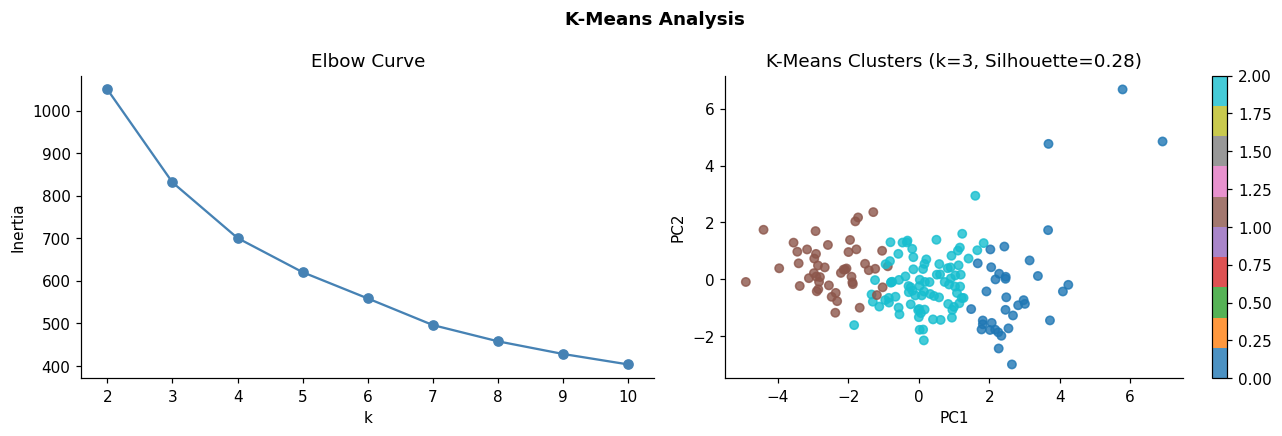

In [9]:
# Elbow curve to find optimal k
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
           for k in range(2, 11)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 11), inertia, marker="o", color="steelblue")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

K_OPT = 3
km = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, km_labels)
print(f"Silhouette Score (k={K_OPT}): {sil:.4f}")

sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="tab10", s=30, alpha=0.8)
axes[1].set_title(f"K-Means Clusters (k={K_OPT}, Silhouette={sil:.2f})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[1])
fig.suptitle("K-Means Analysis", fontweight="bold")
fig.tight_layout()
plt.show()

In [10]:
# Cluster profiles
df["cluster"] = km_labels
df.groupby("cluster")[FEATURES].mean().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## 6. DBSCAN Clustering

DBSCAN → 1 clusters | 21 noise points


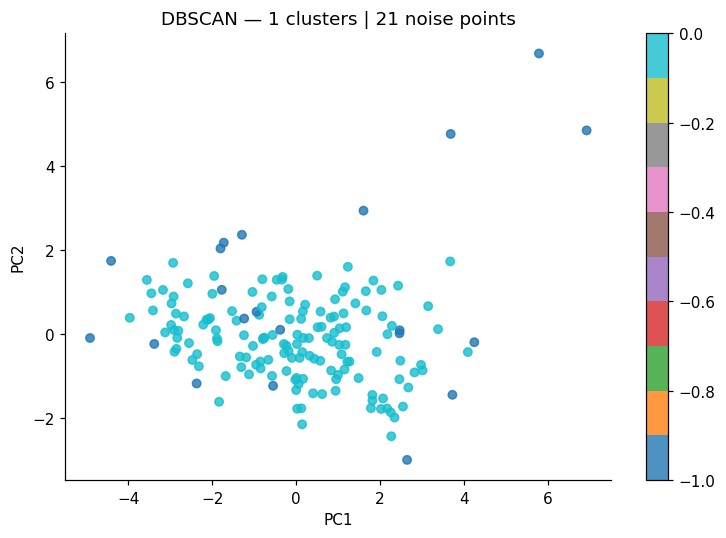

In [11]:
db = DBSCAN(eps=1.8, min_samples=5)
db_labels = db.fit_predict(X_scaled)
n_cl    = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN → {n_cl} clusters | {n_noise} noise points")

fig, ax = plt.subplots(figsize=(7, 5))
sc2 = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap="tab10", s=30, alpha=0.8)
ax.set_title(f"DBSCAN — {n_cl} clusters | {n_noise} noise points")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.colorbar(sc2, ax=ax)
fig.tight_layout()
plt.show()

## 7. Classification Ensemble (Random Forest + GradientBoost)
> Cluster labels from K-Means are used as the classification target.

In [12]:
y = km_labels
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2,
                                            random_state=42, stratify=y)

rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gbt = XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42, verbosity=0)

ens = VotingClassifier([("rf", rf), ("xgb", gbt)], voting="soft")

results = {}
for name, model in [("Random Forest", rf), ("GradientBoost (XGBoost-style)", gbt), ("Ensemble", ens)]:
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring="accuracy")
    results[name] = cv.mean()
    print(f"{name:<35} CV Acc: {cv.mean():.4f} ± {cv.std():.4f}")

Random Forest                       CV Acc: 0.9515 ± 0.0454
GradientBoost (XGBoost-style)       CV Acc: 0.9579 ± 0.0240
Ensemble                            CV Acc: 0.9699 ± 0.0192


In [13]:
# Classification report
ens.fit(X_tr, y_tr)
y_pred = ens.predict(X_te)
print(classification_report(y_te, y_pred,
      target_names=[f"Cluster {i}" for i in range(K_OPT)]))

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      0.90      0.95        10
   Cluster 2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



## 8. Model Comparison

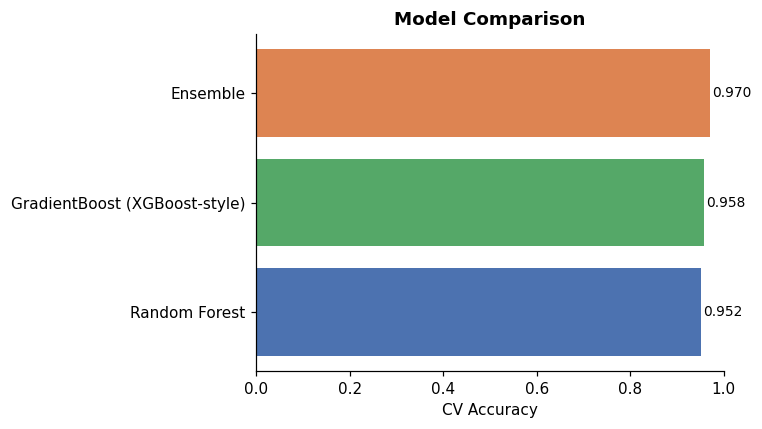

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(list(results.keys()), list(results.values()),
               color=["#4C72B0", "#55A868", "#DD8452"])
ax.set_xlim(0, 1)
ax.set_xlabel("CV Accuracy")
ax.set_title("Model Comparison", fontweight="bold")
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
fig.tight_layout()
plt.show()

## 9. Feature Importance

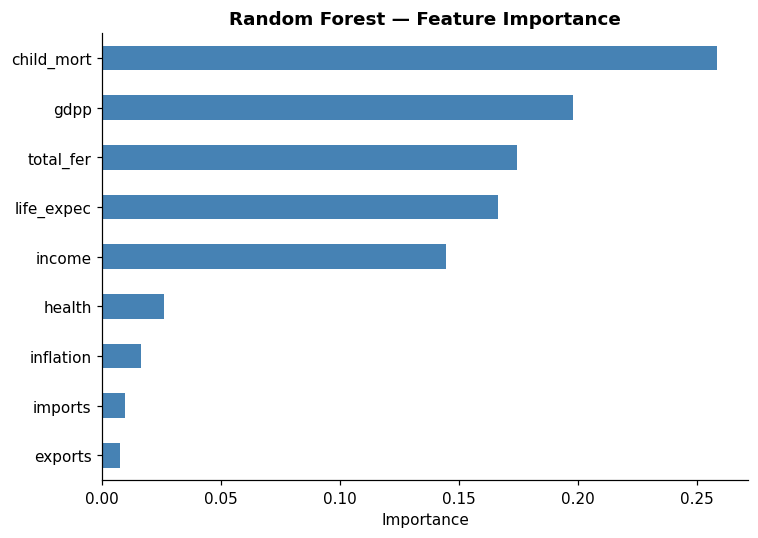

In [15]:
rf.fit(X_tr, y_tr)
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest — Feature Importance", fontweight="bold")
ax.set_xlabel("Importance")
fig.tight_layout()
plt.show()

## 10. PCA — Cumulative Variance

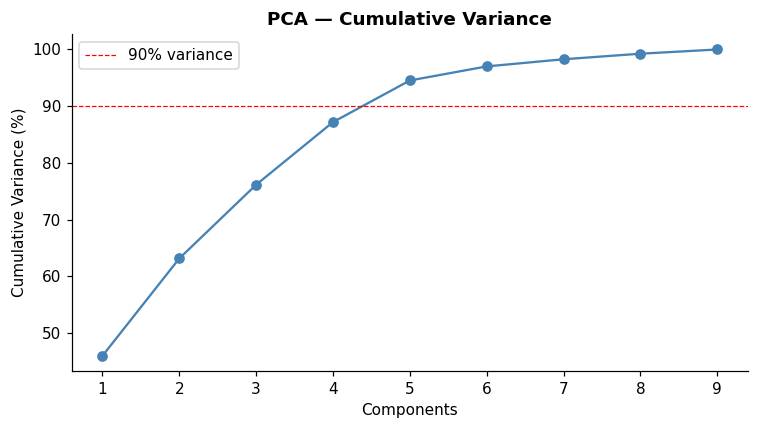

In [16]:
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, marker="o", color="steelblue")
ax.axhline(90, color="red", linestyle="--", linewidth=0.8, label="90% variance")
ax.set_title("PCA — Cumulative Variance", fontweight="bold")
ax.set_xlabel("Components"); ax.set_ylabel("Cumulative Variance (%)")
ax.legend()
fig.tight_layout()
plt.show()